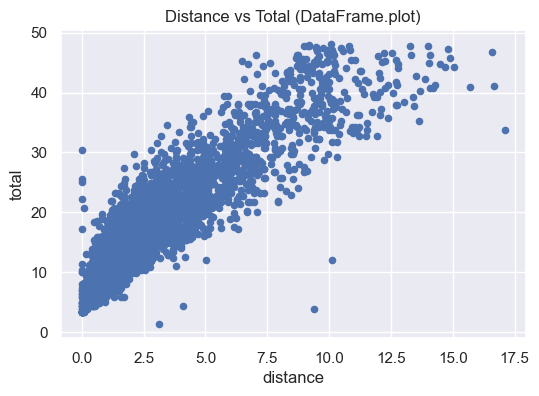

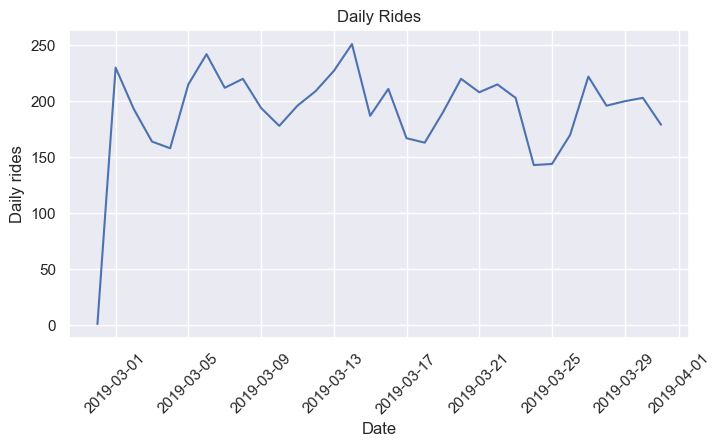

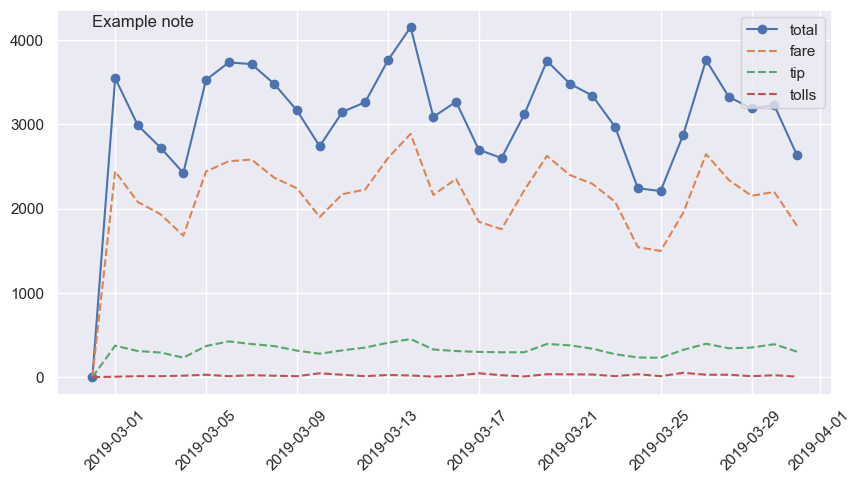

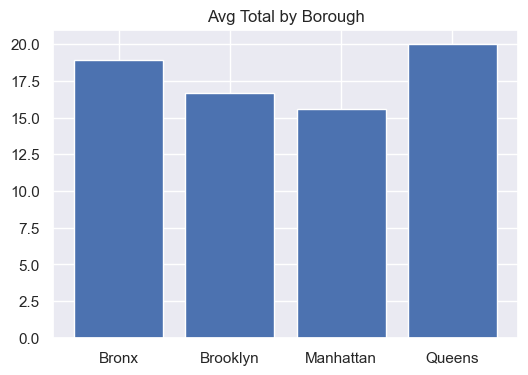

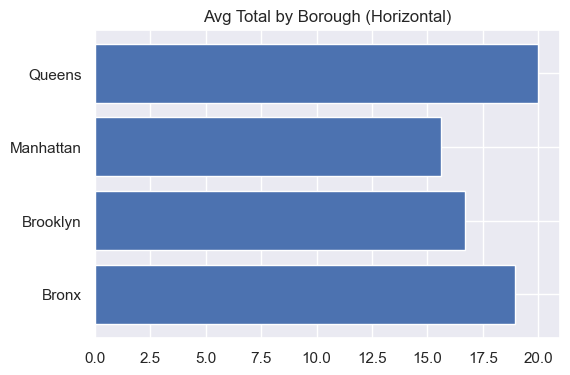

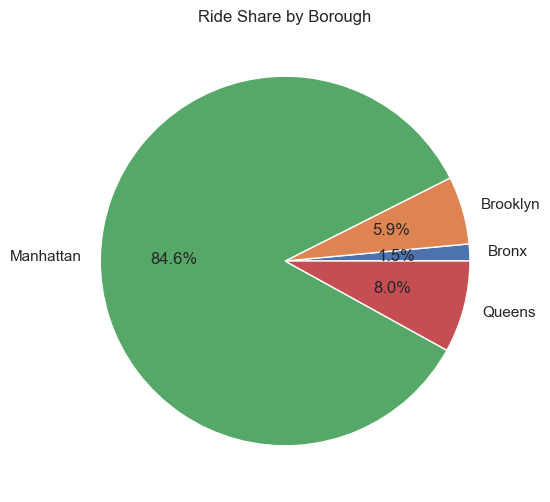

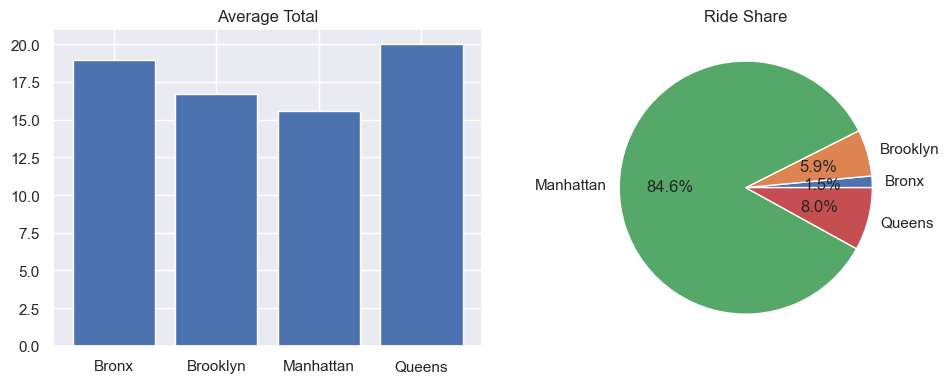

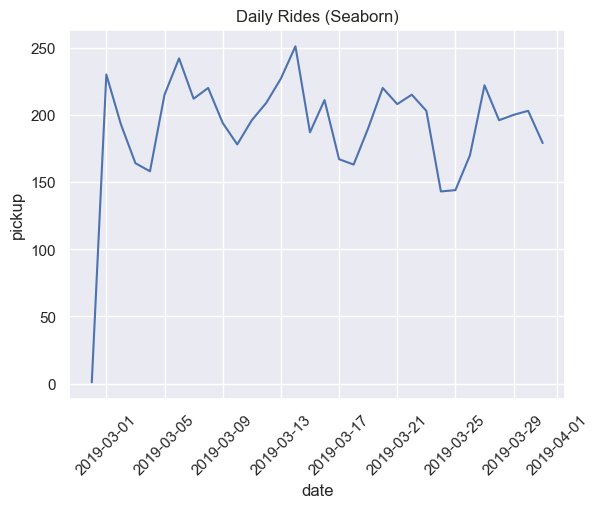

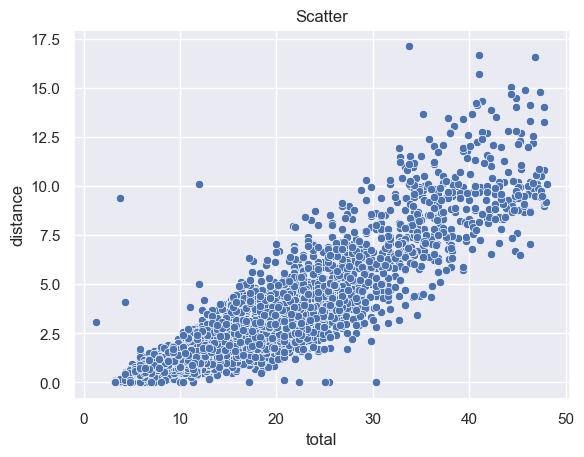

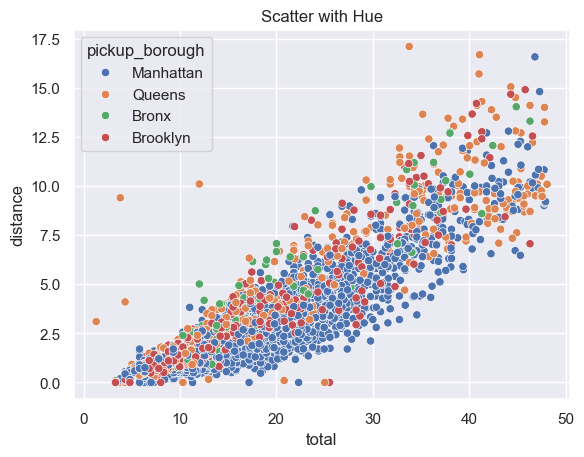

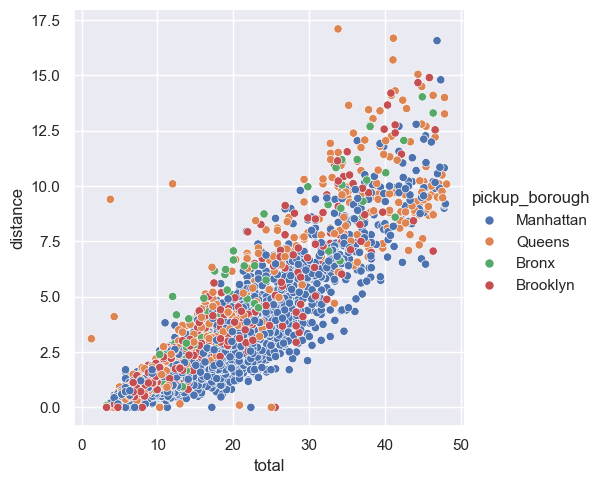

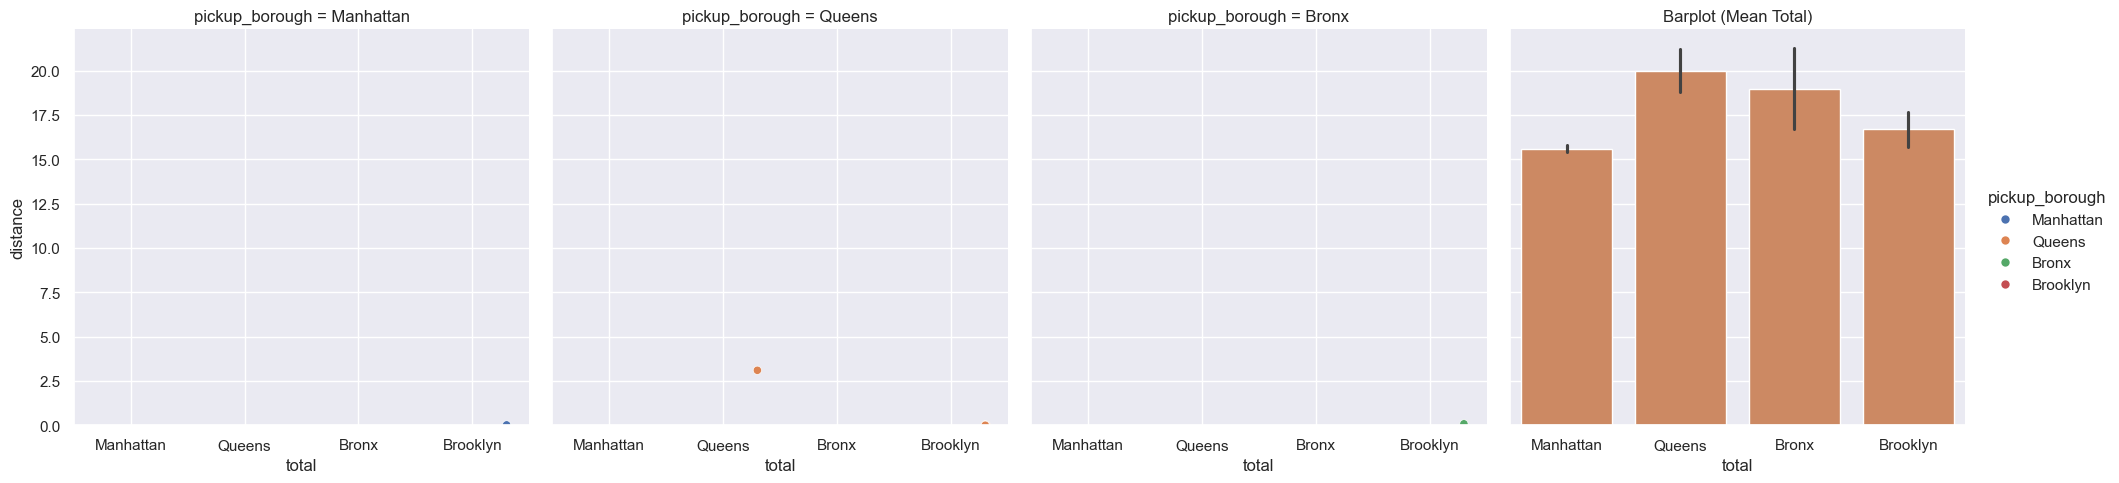

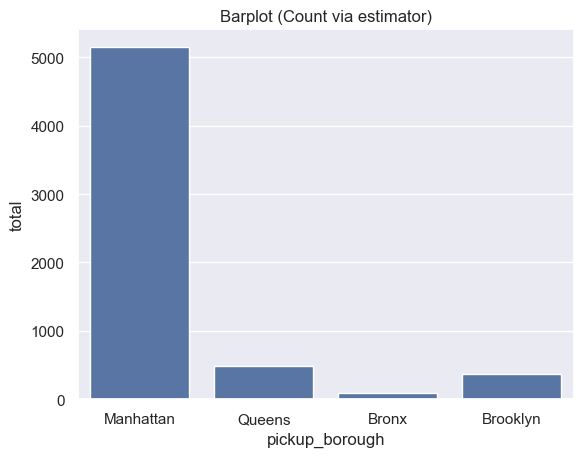

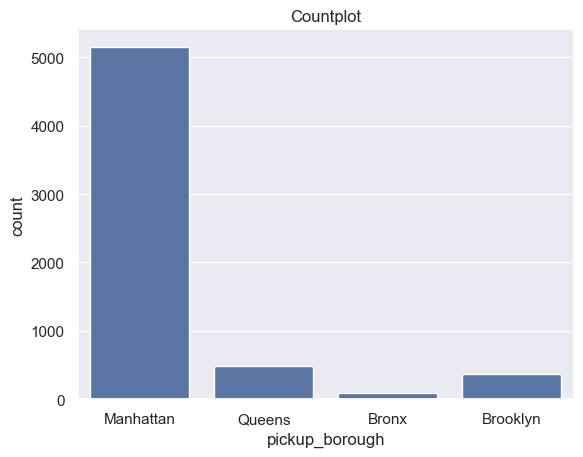

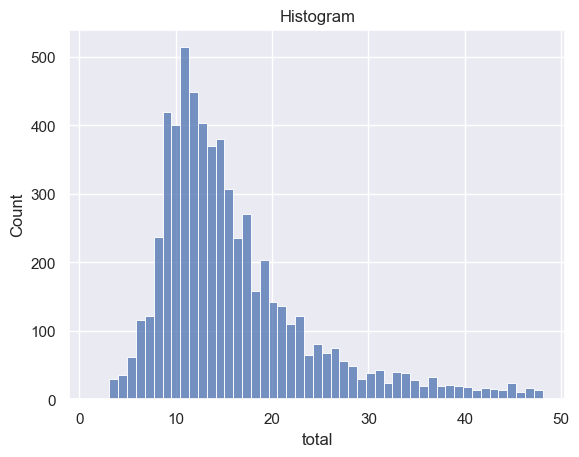

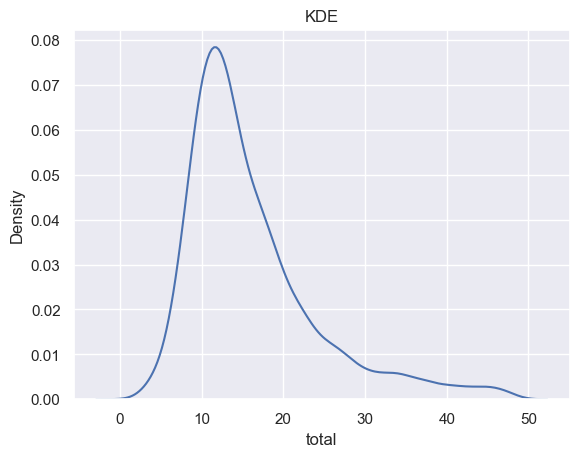

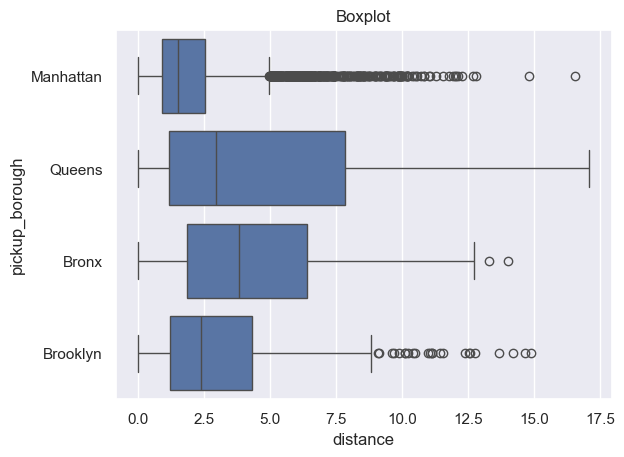

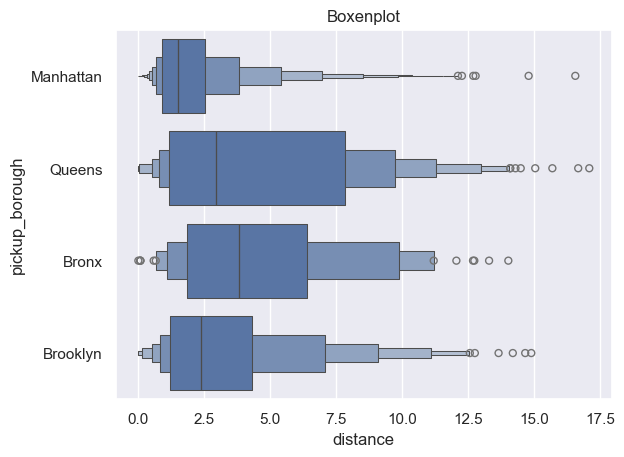

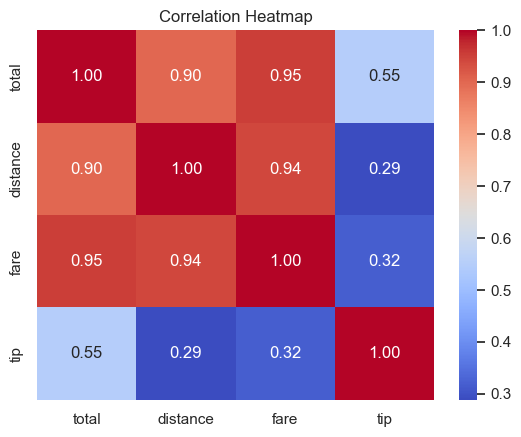

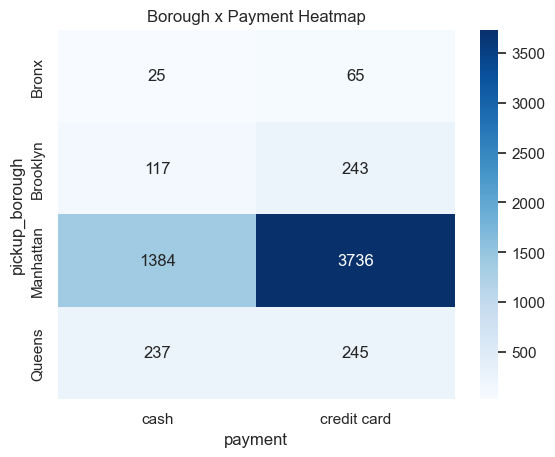

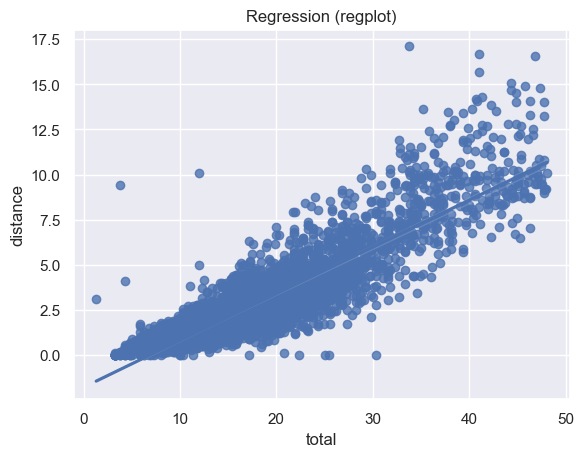

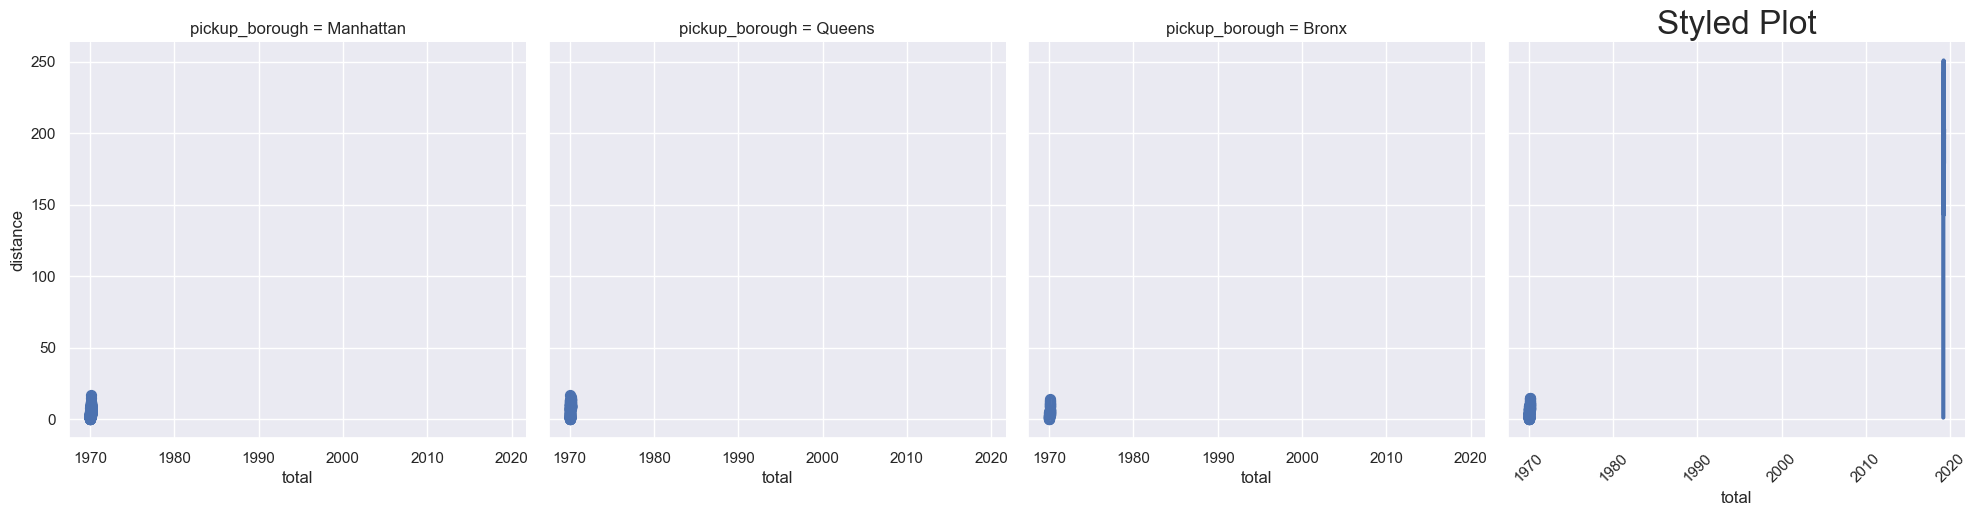

In [3]:


import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from numpy import median


sns.set()

taxis = sns.load_dataset('taxis').copy()

quantile_95 = taxis['total'].quantile(0.95)
taxis = taxis[taxis['total'] <= quantile_95].copy()

taxis['pickup'] = pd.to_datetime(taxis['pickup'])
taxis['dropoff'] = pd.to_datetime(taxis['dropoff'])
taxis.insert(0, 'date', taxis['pickup'].dt.date)

# ------------------------------
# DataFrame.plot (﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿ ﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿)
# ------------------------------

taxis.plot(x='distance', y='total', kind='scatter', figsize=(6,4))
plt.title('Distance vs Total (DataFrame.plot)')
plt.show()

# ------------------------------
# Matplotlib: ﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿ ﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿
# ------------------------------

daily_rides = taxis.groupby('date', as_index=False)['pickup'].count()

plt.figure(figsize=(8,4))
plt.plot('date','pickup', data=daily_rides)
plt.xticks(rotation=45)
plt.xlabel('Date')
plt.ylabel('Daily rides')
plt.title('Daily Rides')
plt.grid(True)
plt.show()

# ------------------------------
# Matplotlib: ﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿ ﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿ + legend + text
# ------------------------------

daily_value = taxis.groupby('date', as_index=False)[['fare','tip','tolls','total']].sum()

plt.figure(figsize=(10,5))
plt.plot(daily_value['date'], daily_value['total'], marker='o', label='total')
plt.plot(daily_value['date'], daily_value['fare'], linestyle='dashed', label='fare')
plt.plot(daily_value['date'], daily_value['tip'], linestyle='dashed', label='tip')
plt.plot(daily_value['date'], daily_value['tolls'], linestyle='dashed', label='tolls')
plt.legend()
plt.xticks(rotation=45)
plt.text(daily_value['date'].min(), daily_value['total'].max(), 'Example note')
plt.grid(True)
plt.show()

# ------------------------------
# ﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿ ﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿ (bar, barh)
# ------------------------------

borough_avg = taxis.groupby('pickup_borough', as_index=False)['total'].mean()

plt.figure(figsize=(6,4))
plt.bar(borough_avg['pickup_borough'], borough_avg['total'])
plt.title('Avg Total by Borough')
plt.show()

plt.figure(figsize=(6,4))
plt.barh(borough_avg['pickup_borough'], borough_avg['total'])
plt.title('Avg Total by Borough (Horizontal)')
plt.show()

# ------------------------------
# Pie chart
# ------------------------------

borough_counts = taxis.groupby('pickup_borough', as_index=False)['pickup'].count()

plt.figure(figsize=(6,6))
plt.pie(borough_counts['pickup'], labels=borough_counts['pickup_borough'], autopct='%.1f%%')
plt.title('Ride Share by Borough')
plt.show()

# ------------------------------
# Subplots (﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿)
# ------------------------------

fig, ax = plt.subplots(1,2, figsize=(10,4))

ax[0].bar(borough_avg['pickup_borough'], borough_avg['total'])
ax[0].set_title('Average Total')

ax[1].pie(borough_counts['pickup'], labels=borough_counts['pickup_borough'], autopct='%.1f%%')
ax[1].set_title('Ride Share')

plt.tight_layout()
plt.show()

# ------------------------------
# Seaborn: lineplot
# ------------------------------

sns.lineplot(daily_rides, x='date', y='pickup')
plt.xticks(rotation=45)
plt.title('Daily Rides (Seaborn)')
plt.show()

# ------------------------------
# Seaborn: scatterplot + hue
# ------------------------------

sns.scatterplot(taxis, x='total', y='distance')
plt.title('Scatter')
plt.show()

sns.scatterplot(taxis, x='total', y='distance', hue='pickup_borough')
plt.title('Scatter with Hue')
plt.show()

# ------------------------------
# Seaborn: relplot
# ------------------------------

sns.relplot(taxis, x='total', y='distance', hue='pickup_borough', kind='scatter')

sns.relplot(taxis, x='total', y='distance', hue='pickup_borough', kind='scatter', col='pickup_borough')

# ------------------------------
# Seaborn: barplot + countplot
# ------------------------------

sns.barplot(taxis, x='pickup_borough', y='total')
plt.title('Barplot (Mean Total)')
plt.show()

sns.barplot(taxis, x='pickup_borough', y='total', estimator=lambda x: len(x))
plt.title('Barplot (Count via estimator)')
plt.show()

sns.countplot(taxis, x='pickup_borough')
plt.title('Countplot')
plt.show()

# ------------------------------
# ﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿: histplot, kdeplot, boxplot, boxenplot
# ------------------------------

sns.histplot(taxis, x='total')
plt.title('Histogram')
plt.show()

sns.kdeplot(taxis['total'])
plt.title('KDE')
plt.show()

sns.boxplot(taxis, x='distance', y='pickup_borough')
plt.title('Boxplot')
plt.show()

sns.boxenplot(taxis, x='distance', y='pickup_borough')
plt.title('Boxenplot')
plt.show()

# ------------------------------
# Heatmap: ﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿
# ------------------------------

corr_matrix = taxis[['total','distance','fare','tip']].corr()

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

# Heatmap ﷿﷿﷿﷿﷿﷿ ﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿ ﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿

crosstab = pd.crosstab(taxis['pickup_borough'], taxis['payment'])

sns.heatmap(crosstab, annot=True, fmt='d', cmap='Blues')
plt.title('Borough x Payment Heatmap')
plt.show()

# ------------------------------
# ﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿ ﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿: regplot, lmplot
# ------------------------------

sns.regplot(taxis, x='total', y='distance')
plt.title('Regression (regplot)')
plt.show()

sns.lmplot(taxis, x='total', y='distance', col='pickup_borough', x_estimator=median)

# ------------------------------
# ﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿ ﷿﷿﷿﷿ ﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿
# ------------------------------

sns.set_style('darkgrid')
sns.set_context('poster')

sns.lineplot(daily_rides, x='date', y='pickup')
plt.xticks(rotation=45)
plt.title('Styled Plot')
plt.show()

sns.set_context('notebook')
